# Calculate `VPD` (2004-2025)

**notebook version**: `2` (21 Jul 2026)

## ℹ️ About this notebook

Computes vapour pressure deficit `VPD` from the two products that precede it, and stores it to the
external data folder. No download, no gap-filling: `02` and `04` must be run first.

- `TA_T1_47_1_gfXG` — gap-filled air temperature from notebook `02`, **complete**
- `RH_T1_47_1` — relative humidity from notebook `04`, **complete** (reconstructed where the tower
  did not measure)

`VPD` follows from `TA` and `RH` by formula. Both inputs are complete, so **VPD is computed for
every record** — there are no gaps to model, and the XGBoost step of earlier versions is gone.

**Output columns:**

- `VPD_T1_47_1` — the computed series (kPa, complete).
- `FLAG_VPD_T1_47_1_ISFILLED` — what each record was computed from; `0` = measured `TA` **and**
  measured `RH`, `>0` = one input was gap-filled or reconstructed (see `FLAG_LEGEND`).

Because `VPD` is **derived**, `0` still means "measured and nothing else": a record can be computed
by the formula yet rest on a gap-filled `TA` or a reconstructed `RH`, which the flag records.

***

## 📇 Data sources

Both inputs are parquet files in the external data folder, written by earlier notebooks in this
stage. Nothing is read from the database here.

| file | column used | from | completeness |
|---|---|---|---|
| `02_METEO_TA_GAPFILLED_2004-2025` | `TA_T1_47_1_gfXG` | notebook `02` | complete |
| `02_METEO_TA_GAPFILLED_2004-2025` | `FLAG_TA_T1_47_1_ISFILLED` | notebook `02` | complete |
| `04_METEO_RH_CORRECTED_2004-2025` | `RH_T1_47_1` | notebook `04` | complete |
| `04_METEO_RH_CORRECTED_2004-2025` | `FLAG_RH_T1_47_1_MISSING` | notebook `04` | complete |

Both inputs are complete, so `VPD` is computed for every record. The two input flags are read as
well, not just the values: they are what makes the provenance of each computed `VPD` knowable —
without them every computed record would look equally measured.

## ⏱️ Timestamp convention

Every input file already carries a sanitised, continuous 30MIN `TIMESTAMP_MID` index in local time,
produced by the `TimestampSanitizer` call in the notebook that wrote it. This notebook does not
shift, resample or geolocate anything: it asserts that the two indices agree and computes `VPD` on
them as they are.

***

## ⚙️ Settings

### Data settings

In [1]:
REQUIRED_TIME_RESOLUTION = '30min'  # Expected resolution of the input files; asserted below

TARGET = "VPD_T1_47_1"  # variable computed and exported here

# Inputs: products of the earlier notebooks of this stage, in the external data folder.
# There is no database download in this notebook.
TA_FILE = "02_METEO_TA_GAPFILLED_2004-2025"
TA_COL = "TA_T1_47_1_gfXG"
TA_FLAGCOL = "FLAG_TA_T1_47_1_ISFILLED"

RH_FILE = "04_METEO_RH_CORRECTED_2004-2025"
RH_COL = "RH_T1_47_1"
RH_FLAGCOL = "FLAG_RH_T1_47_1_MISSING"
RH_FLAG_RECONSTRUCTED = 3      # notebook 04: reconstructed from NABEL at 49 m
RH_FLAG_RECONSTRUCTED_LAE = 4  # notebook 04: reconstructed from MeteoSwiss Laegern at 2.5 km


# Output: data files live in the external (untracked) data folder, with the same
# numeric prefix as this notebook.
OUTNAME = "07_METEO_VPD_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Plausible VPD at this site, in kPa. VPD is zero at saturation and cannot be negative; the upper
# bound is generous (the record maximum is around 4 kPa) and only has to catch a unit or formula
# error, which would be off by a factor of 10 (hPa) or more.
VPD_PLAUSIBLE_KPA = (0.0, 10.0)

### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-21 02:09:50
diive version: v0.91.0


In [3]:
# Result flags. VPD is DERIVED and, since notebooks 02 and 04 now export complete TA and RH, it is
# COMPUTED for every record -- no VPD model runs here, so there are no modelled flags (1/2/4).
#
# A computed record still need not rest on two measurements: notebook 02 may have gap-filled the TA,
# or notebook 04 may have reconstructed the RH (from NABEL, or from MeteoSwiss Laegern). Those are
# not measurements, so they must not read 0.
#
# The 01-03 convention holds: 0 means measured and nothing else, so a downstream `flag == 0` filter
# stays conservative.
FLAG_LEGEND = {
    0: '0 = computed from measured TA and measured RH',
    5: '5 = computed from measured RH and gap-filled TA',
    6: '6 = computed from RH reconstructed from NABEL at 49 m (TA measured or gap-filled)',
    7: '7 = computed from RH reconstructed from MeteoSwiss Laegern at 2.5 km (TA measured or gap-filled)',
}
# Every VPD record follows from the formula -- all flags are "computed" flags.
COMPUTED_FLAGS = (0, 5, 6, 7)

### Helper functions

Three helpers, each with the job of failing loudly rather than quietly doing nothing:

- `load_product()` reads one of the input files and **refuses** anything whose index is not a
  continuous, duplicate-free 30MIN series or that is missing the columns asked for. Every later
  step aligns three files on a shared index, and a silently mis-shaped input would produce a
  `VPD` full of `NaN` that still had the right length.
- `short_gap_mask()` selects whole gap runs no longer than a limit. Same helper as notebook `02`.
- `check_vpd_range()` is the physical guard on the result, used twice: on the computed `VPD` and
  again on the exported series.

In [4]:
def load_product(filename: str, columns: list[str]) -> pd.DataFrame:
    """Load one stage-10 product and verify it is usable as an input here.

    Raises rather than returning a frame that would quietly poison the merge: missing columns, a
    non-30MIN index, duplicate timestamps or an index with holes all stop the notebook.
    """
    filepath = Path(OUTPATH) / f"{filename}.parquet"
    if not filepath.is_file():
        raise FileNotFoundError(
            f"{filepath} does not exist. Run the notebook that produces it before this one.")

    df = dv.load_parquet(filepath=str(filepath))

    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"{filename}: expected column(s) {missing}, found {list(df.columns)}.")
    if df.index.duplicated().any():
        raise ValueError(f"{filename}: {int(df.index.duplicated().sum())} duplicate timestamps.")

    steps = df.index.to_series().diff().dropna().unique()
    expected = pd.Timedelta(REQUIRED_TIME_RESOLUTION)
    if len(steps) != 1 or steps[0] != expected:
        raise ValueError(
            f"{filename}: index is not a continuous {REQUIRED_TIME_RESOLUTION} series "
            f"(found step(s) {list(steps)}).")

    out = df[columns].copy()
    print(f"  {filename:<38} {out.index[0]} -> {out.index[-1]}  ({len(out):,} records)")
    return out


def short_gap_mask(series: pd.Series, limit: int) -> pd.Series:
    """True where `series` is missing AND its whole gap is at most `limit` records long.

    Whole runs are selected explicitly. Using pandas' `interpolate(limit=)` instead would fill
    the first `limit` records of a long gap as well, which is not wanted: those values would sit
    on a straight line spanning the entire gap.
    """
    missing = series.isna()
    run_length = missing.groupby((~missing).cumsum()).transform('sum')
    return missing & (run_length <= limit)


def check_vpd_range(series: pd.Series, label: str) -> None:
    """Assert that every value present is plausible VPD in kPa.

    A formula slip or a unit mix-up (hPa instead of kPa) shows up here as a factor of 10, and a
    negative value means either an RH above 100% survived upstream or a model prediction was not
    clipped.
    """
    lo, hi = VPD_PLAUSIBLE_KPA
    values = series.dropna()
    if values.empty:
        raise ValueError(f"{label}: no values at all.")
    if values.min() < lo or values.max() > hi:
        raise ValueError(
            f"{label}: range {values.min():.3f}..{values.max():.3f} kPa is outside the plausible "
            f"{lo}..{hi} kPa. VPD is ~0-4 kPa here; a factor of 10 means hPa.")
    print(f"  {label:<34} n={len(values):>7,}  "
          f"median {float(values.median()):.3f}  range {values.min():.3f}..{values.max():.3f} kPa")

#### The guards actually guard

Both `load_product()` and `check_vpd_range()` can only earn their place if their failure path
works, so it is exercised here. Each of these must raise. If this cell prints anything other than
caught exceptions, do not trust the rest of the notebook.

In [5]:
# 1. A column that does not exist must be refused, not silently dropped.
try:
    load_product(TA_FILE, [TA_COL, 'NO_SUCH_COLUMN'])
    raise AssertionError("load_product accepted a missing column - the guard is broken.")
except ValueError as exc:
    print(f"OK, raised as intended:\n  {exc}\n")

# 2. VPD in hPa (i.e. 10x too large) must be refused.
try:
    check_vpd_range(pd.Series([5.0, 12.0, 30.0]), 'VPD in hPa by mistake')
    raise AssertionError("check_vpd_range accepted hPa-magnitude values - the guard is broken.")
except ValueError as exc:
    print(f"OK, raised as intended:\n  {exc}\n")

# 3. A negative VPD must be refused.
try:
    check_vpd_range(pd.Series([0.4, -0.01, 1.2]), 'VPD with a negative value')
    raise AssertionError("check_vpd_range accepted a negative VPD - the guard is broken.")
except ValueError as exc:
    print(f"OK, raised as intended:\n  {exc}")

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\02_METEO_TA_GAPFILLED_2004-2025.parquet (0.147 seconds).

OK, raised as intended:
  02_METEO_TA_GAPFILLED_2004-2025: expected column(s) ['NO_SUCH_COLUMN'], found ['TA_T1_47_1_gfXG', 'FLAG_TA_T1_47_1_ISFILLED'].

OK, raised as intended:
  VPD in hPa by mistake: range 5.000..30.000 kPa is outside the plausible 0.0..10.0 kPa. VPD is ~0-4 kPa here; a factor of 10 means hPa.

OK, raised as intended:
  VPD with a negative value: range -0.010..1.200 kPa is outside the plausible 0.0..10.0 kPa. VPD is ~0-4 kPa here; a factor of 10 means hPa.


***

## ⬇️ Load inputs

No database connection is needed. The three files below are read from the external data folder,
each of them the output of an earlier notebook in this stage.

In [6]:
print("Loading stage-10 products:")
ta_in = load_product(TA_FILE, [TA_COL, TA_FLAGCOL])
rh_in = load_product(RH_FILE, [RH_COL, RH_FLAGCOL])

Loading stage-10 products:


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\02_METEO_TA_GAPFILLED_2004-2025.parquet (0.018 seconds).

  02_METEO_TA_GAPFILLED_2004-2025        2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\04_METEO_RH_CORRECTED_2004-2025.parquet (0.009 seconds).

  04_METEO_RH_CORRECTED_2004-2025        2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)


### Align on one index

The three files are expected to cover the same period, but that is asserted rather than assumed.
The working index is their **intersection**, so a future input with a shorter record shortens the
product instead of filling the difference with `NaN` that would later be modelled as if it were a
genuine gap.

In [7]:
common_index = ta_in.index.intersection(rh_in.index)
common_index.name = ta_in.index.name

for _label, _df in [('TA', ta_in), ('RH', rh_in)]:
    _dropped = len(_df) - len(common_index)
    print(f"{_label:<6} {len(_df):>7,} records, {_dropped:>5,} outside the common index")
assert len(common_index) > 0, "the two inputs do not overlap at all"

df = pd.DataFrame(index=common_index)
df[TA_COL] = ta_in[TA_COL]
df[TA_FLAGCOL] = ta_in[TA_FLAGCOL]
df[RH_COL] = rh_in[RH_COL]
df[RH_FLAGCOL] = rh_in[RH_FLAGCOL]

print(f"\nWorking index: {df.index[0]} -> {df.index[-1]}  ({len(df):,} records)")

# Both inputs arrive complete, so VPD can be computed for every record.
assert df[TA_COL].notna().all(), f"{TA_COL} has gaps but notebook 02 exports a complete series"
assert df[RH_COL].notna().all(), f"{RH_COL} has gaps but notebook 04 now exports a complete series"
assert df[TA_FLAGCOL].notna().all(), f"{TA_FLAGCOL} has missing flags"
assert df[RH_FLAGCOL].notna().all(), f"{RH_FLAGCOL} has missing flags"
print(f"{RH_COL}: complete, so VPD is computed for every record")
df

TA     385,728 records,     0 outside the common index
RH     385,728 records,     0 outside the common index

Working index: 2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)
RH_T1_47_1: complete, so VPD is computed for every record


,TA_T1_47_1_gfXG,FLAG_TA_T1_47_1_ISFILLED,RH_T1_47_1,FLAG_RH_T1_47_1_MISSING
TIMESTAMP_MIDDLE,,,,
2004-01-01 00:15:00,6.938439,2,97.718962,3
2004-01-01 00:45:00,6.938439,2,96.918962,3
2004-01-01 01:15:00,8.341139,2,93.552296,3
2004-01-01 01:45:00,8.341139,2,92.652296,3
2004-01-01 02:15:00,8.205807,2,93.985629,3
...,...,...,...,...
2025-12-31 21:45:00,-3.081644,0,42.332976,0
2025-12-31 22:15:00,-3.084372,0,39.230344,0
2025-12-31 22:45:00,-3.423939,0,55.771803,0


### Provenance carried by the inputs

Where the non-`0` codes sit decides which `VPD` records can be labelled `0` further down. Notebook
`02`'s flag names the model that produced a `TA`; notebook `04`'s flag says whether an `RH` was
measured at 47 m, reconstructed from NABEL, or is simply absent.

In [8]:
_ta_counts = df[TA_FLAGCOL].value_counts().sort_index()
_rh_counts = df[RH_FLAGCOL].value_counts().sort_index()

print(f"{TA_FLAGCOL} (0 = measured, > 0 = gap-filled by notebook 02):")
display(pd.DataFrame({'count': _ta_counts, '%': (100 * _ta_counts / len(df)).round(2)}))

print(f"{RH_FLAGCOL} (0 = measured, 3 = reconstructed from NABEL, 4 = reconstructed from Laegern):")
display(pd.DataFrame({'count': _rh_counts, '%': (100 * _rh_counts / len(df)).round(2)}))

FLAG_TA_T1_47_1_ISFILLED (0 = measured, > 0 = gap-filled by notebook 02):


,count,%
FLAG_TA_T1_47_1_ISFILLED,,
0,369065,95.68
1,14912,3.87
2,1573,0.41
4,178,0.05


FLAG_RH_T1_47_1_MISSING (0 = measured, 3 = reconstructed from NABEL, 4 = reconstructed from Laegern):


,count,%
FLAG_RH_T1_47_1_MISSING,,
0,369079,95.68
3,15729,4.08
4,920,0.24


***

## 🧮 Calculate `VPD`

`VPD` is the difference between the saturation vapour pressure at the given air temperature and the
actual vapour pressure, so it follows from `TA` and `RH` alone:

$$
\mathrm{VPD} = e_{sat}(T_a)\left(1 - \frac{\mathrm{RH}}{100}\right)
$$

`diive`'s `calc_vpd_from_ta_rh()` implements this with the Magnus coefficients used by **ReddyProc**
(Kolle Logger Tools Software 2012, valid for water between 0 and 100 °C) and returns **kPa**:

```
VPD [hPa] = 6.1078 * (1 - RH/100) * exp(17.08085 * TA / (234.175 + TA))
```

Two consequences of the formula are worth stating before the numbers appear:

- **`VPD` is zero at saturation and never negative.** `RH` arrives from notebook `04` already
  capped at 100%, so the computed series cannot be negative. The model predictions later on can be,
  and are clipped where they are.
- **`VPD` is missing exactly where `RH` is missing**, because `TA` is complete. So the gap pattern
  of the computed series is `RH`'s gap pattern, and that is checked rather than assumed.

In [9]:
df[TARGET] = dv.variables.calc_vpd_from_ta_rh(df=df, rh_col=RH_COL, ta_col=TA_COL)

print("Computed VPD:")
check_vpd_range(df[TARGET], TARGET)

# The gap pattern must be RH's gap pattern and nothing else. If these ever disagree, either TA
# arrived incomplete or the formula produced NaN from valid inputs; both are bugs, not data.
_vpd_missing = df[TARGET].isna()
_rh_missing = df[RH_COL].isna()
print(f"\nVPD missing: {int(_vpd_missing.sum()):,}   RH missing: {int(_rh_missing.sum()):,}")
assert _vpd_missing.equals(_rh_missing), \
    "VPD is missing where RH is not (or vice versa) - TA incomplete, or a formula problem"
print("VPD gaps are exactly RH's gaps, as expected.")

Computed VPD:
  VPD_T1_47_1                        n=385,728  median 0.171  range 0.000..4.036 kPa

VPD missing: 0   RH missing: 0
VPD gaps are exactly RH's gaps, as expected.


### Provenance of the computed `VPD`

Every record that has a value at this point was computed by the formula, so **none of it is
modelled**. That is not the same as measured, and this is where the distinction is written down
rather than left to be inferred later.

A computed record gets:

- `0` if both inputs were measurements (`TA` flag `0` **and** `RH` flag `0`)
- `5` if `RH` was measured but `TA` came from notebook `02`'s gap-filling
- `6` if `RH` was reconstructed from the NABEL sensor at 49 m, whatever `TA` was

`6` outranks `5` because it is the larger error: notebook `04` puts about **3 % RH** of uncertainty
on a reconstructed value, and `RH` enters the formula linearly, so at typical summer conditions
that is a few tenths of a kPa — considerably more than a gap-filled `TA` contributes.

The mask is built **now**, before any gap-filling writes values into the missing records. Doing it
afterwards is precisely the mistake notebook `03` records: a later step that puts a value into an
empty record makes a modelled value indistinguishable from a measured one.

In [10]:
# TA and RH are complete, so VPD is computed for every record. The flag records what each VPD
# rests on; there is no gap-filling to merge in.
computed = df[TARGET].notna()
assert computed.all(), "VPD is not complete though TA and RH are - a formula problem"

flag = pd.Series(pd.NA, index=df.index, dtype='Int64', name=f"FLAG_{TARGET}_ISFILLED")
flag[(df[TA_FLAGCOL] == 0) & (df[RH_FLAGCOL] == 0)] = 0                 # both measured
flag[(df[TA_FLAGCOL] > 0) & (df[RH_FLAGCOL] == 0)] = 5                  # RH measured, TA gap-filled
flag[df[RH_FLAGCOL] == RH_FLAG_RECONSTRUCTED] = 6                       # RH from NABEL (any TA)
flag[df[RH_FLAGCOL] == RH_FLAG_RECONSTRUCTED_LAE] = 7                   # RH from Laegern (any TA)

# The RH flag partitions the record into {0, 3, 4}, so every record is classified exactly once.
assert flag.notna().all(), "a record was left unclassified"
assert set(int(x) for x in flag.unique()).issubset(set(FLAG_LEGEND)), "unknown flag code"

_counts = flag.value_counts().sort_index()
display(pd.DataFrame({'count': _counts.astype(int),
                      '% of record': (100 * _counts / len(df)).round(2)}).rename(index=FLAG_LEGEND))
print(f"All {len(df):,} records computed  |  purely measured (flag 0): {100 * (flag == 0).mean():.2f}%")

,count,% of record
FLAG_VPD_T1_47_1_ISFILLED,,
0 = computed from measured TA and measured RH,369056,95.68
5 = computed from measured RH and gap-filled TA,23,0.01
6 = computed from RH reconstructed from NABEL at 49 m (TA measured or gap-filled),15729,4.08
7 = computed from RH reconstructed from MeteoSwiss Laegern at 2.5 km (TA measured or gap-filled),920,0.24


All 385,728 records computed  |  purely measured (flag 0): 95.68%


### Plots: the computed series and its inputs

The two heatmaps of the inputs and the one of `VPD` should share the same white areas, since `TA`
is complete and `RH` is not. `VPD` has a strong diurnal and seasonal structure — high on summer
afternoons, near zero at night and in winter — and a heatmap that does not show it would mean the
timestamps or the formula are wrong.

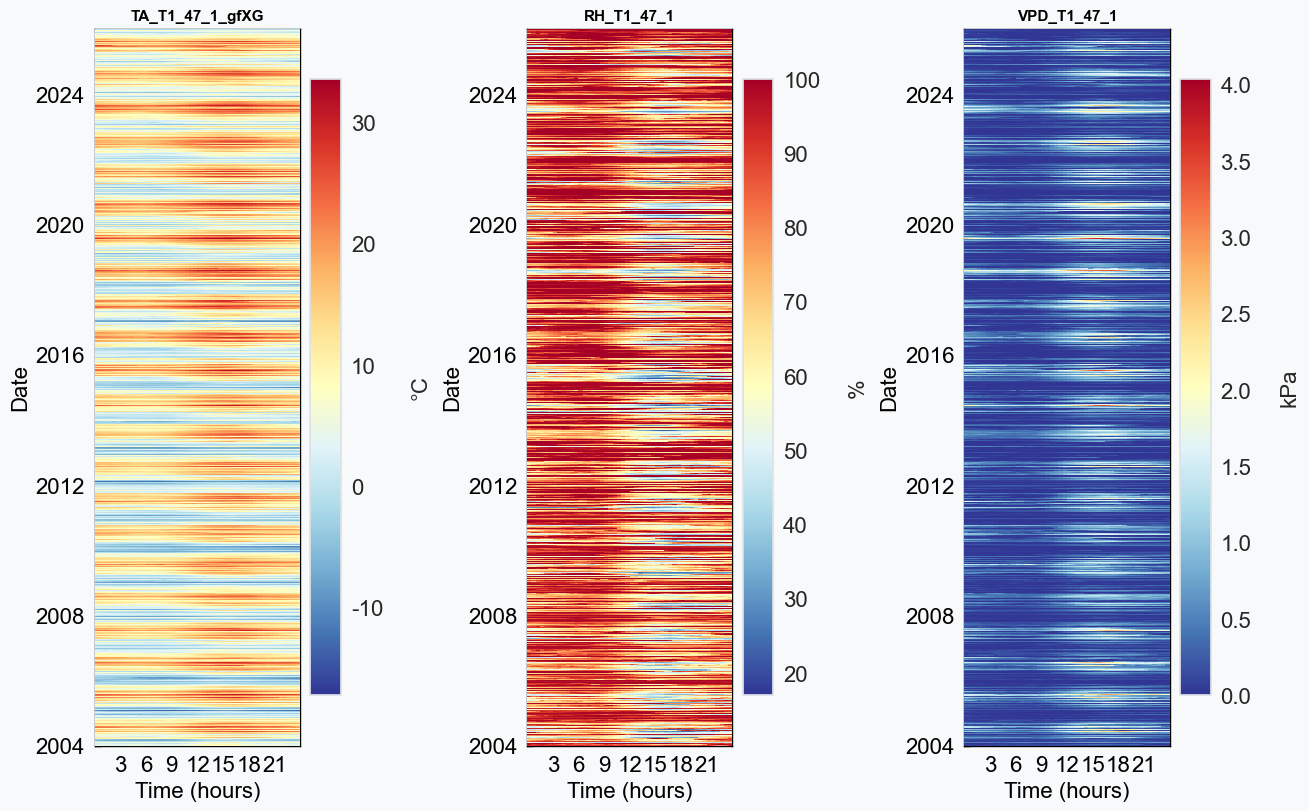

In [11]:
fig, axs = plt.subplots(ncols=3, figsize=(13, 8), dpi=100, layout='constrained')
for _ax, _col, _z, _dig in [(axs[0], TA_COL, '°C', 0),
                            (axs[1], RH_COL, '%', 0),
                            (axs[2], TARGET, 'kPa', 1)]:
    dv.plotting.HeatmapDateTime(series=df[_col]).plot(
        ax=_ax, cb_digits_after_comma=_dig, zlabel=_z,
        format_style=dv.plotting.FormatStyle(title=_col, title_fontsize=11))

Text(0.5, 1.0, 'Median VPD by month (peaks in summer)')

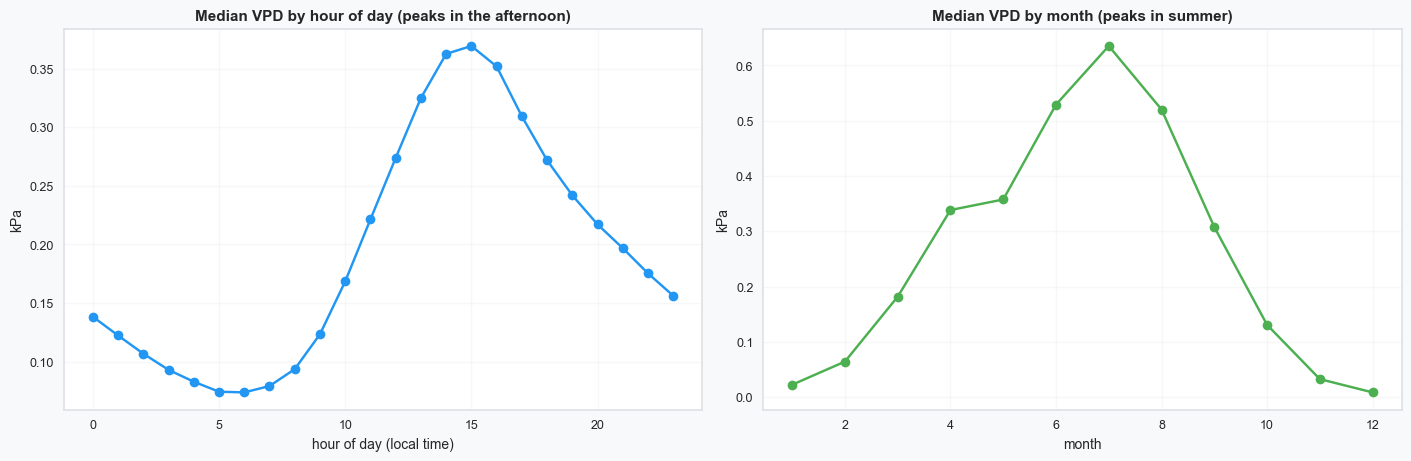

In [12]:
# Diurnal and seasonal behaviour of the computed VPD, as a second check that it is physical.
fig, axs = plt.subplots(ncols=2, figsize=(14, 4.5), dpi=100, layout='constrained')

_by_hour = df[TARGET].groupby(df.index.hour).median()
_by_hour.plot(ax=axs[0], marker='o', color='#2196F3')
axs[0].set_xlabel('hour of day (local time)')
axs[0].set_ylabel('kPa')
axs[0].set_title('Median VPD by hour of day (peaks in the afternoon)', fontsize=11)

_by_month = df[TARGET].groupby(df.index.month).median()
_by_month.plot(ax=axs[1], marker='o', color='#4CAF50')
axs[1].set_xlabel('month')
axs[1].set_ylabel('kPa')
axs[1].set_title('Median VPD by month (peaks in summer)', fontsize=11)

***

## ➡️ Prepare dataframe for export

In [13]:
VALCOL = TARGET   # VPD_T1_47_1 - a computed series, so no _gfXG suffix
FLAGCOL = f"FLAG_{TARGET}_ISFILLED"

export_df = pd.concat([df[VALCOL], flag.astype(int).rename(FLAGCOL)], axis=1)
export_df

,VPD_T1_47_1,FLAG_VPD_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.022776,6
2004-01-01 00:45:00,0.030765,6
2004-01-01 01:15:00,0.070865,6
2004-01-01 01:45:00,0.080756,6
2004-01-01 02:15:00,0.065496,6
...,...,...
2025-12-31 21:45:00,0.280473,0
2025-12-31 22:15:00,0.295503,0
2025-12-31 22:45:00,0.209658,0


Sanity check: the exported series must be complete (no gaps), non-negative, physically plausible in
kPa, and the index must be continuous 30MIN with no duplicates. Every record must carry a flag.

`FLAG_VPD_T1_47_1_ISFILLED` travels with the product so downstream users can tell the three classes
apart. Flag `0` is computed from two measurements; `5` and `6` are computed but rest on a filled or
reconstructed input; `1`, `2` and `4` were produced by the gap-filling here.

In [14]:
print(f"Records:         {len(export_df):,}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum()}")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()}")
print(f"Negative values: {(export_df[VALCOL] < 0).sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      "
      f"{(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")
print(f"Index:           {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Min / max:       {export_df[VALCOL].min():.3f} / {export_df[VALCOL].max():.3f} kPa")

assert export_df[VALCOL].notna().all(), "the exported series is not complete"
assert (export_df[VALCOL] >= 0).all(), "VPD cannot be negative"
assert export_df[FLAGCOL].notna().all(), "a record has no flag"
assert export_df[FLAGCOL].isin(COMPUTED_FLAGS).all(), "every VPD record must be computed"
print("\nSanity checks passed: complete, non-negative, every record computed.")

Records:         385,728
Missing values:  0
Missing flags:   0
Negative values: 0
Duplicate index: 0
Index gaps:      0
Index:           2004-01-01 00:15:00 -> 2025-12-31 23:45:00
Min / max:       0.000 / 4.036 kPa

Sanity checks passed: complete, non-negative, every record computed.


### Per-year statistics

The per-year median is the check that nothing stepped: `VPD` is weather, so the interannual spread
should be small and there should be no jump at 2018/2019, where the NABEL sensor behind the `RH`
reconstruction ends and the fill switches from `6` to `1`.

`measured_%` shows how much of each year rests on two genuine measurements. It is lowest where
notebook `04` had to reconstruct `RH` and where notebook `02` had to fill `TA`.

In [15]:
_yr = export_df[VALCOL].groupby(export_df.index.year).agg(['count', 'median', 'min', 'max', 'std'])
_yr['measured_%'] = (100 * (export_df[FLAGCOL] == 0)
                     .groupby(export_df.index.year).mean()).round(2)
_yr['reconstructed_RH_%'] = (100 * export_df[FLAGCOL].isin((6, 7))
                             .groupby(export_df.index.year).mean()).round(2)
display(_yr.round(3))

_med = _yr['median']
print(f"Yearly medians between {_med.min():.3f} and {_med.max():.3f} kPa "
      f"(spread {_med.max() - _med.min():.3f} kPa)")

,count,median,min,max,std,measured_%,reconstructed_RH_%
TIMESTAMP_MIDDLE,,,,,,,
2004,17568,0.177,0.000,2.834,0.410,28.02,71.98
2005,17520,0.168,0.005,2.939,0.431,99.81,0.19
2006,17520,0.179,0.000,3.309,0.453,99.85,0.15
2007,17520,0.180,0.000,3.143,0.404,99.93,0.07
2008,17568,0.181,0.002,2.351,0.361,99.89,0.11
2009,17520,0.191,0.000,2.766,0.403,97.23,2.77
2010,17520,0.139,0.000,2.857,0.414,99.04,0.96
2011,17520,0.226,0.000,3.002,0.443,99.88,0.12
2012,17568,0.173,0.000,3.075,0.411,92.81,7.17


Yearly medians between 0.099 and 0.234 kPa (spread 0.135 kPa)


,0 = computed from measured TA and measured RH,5 = computed from measured RH and gap-filled TA,6 = computed from RH reconstructed from NABEL at 49 m (TA measured or gap-filled),7 = computed from RH reconstructed from MeteoSwiss Laegern at 2.5 km (TA measured or gap-filled)
year,,,,
2004,4922,0,12640,6
2005,17486,0,10,24
2006,17493,0,27,0
2007,17507,0,13,0
2008,17548,0,20,0
2009,17034,0,486,0
2010,17351,0,169,0
2011,17499,0,11,10
2012,16305,3,1260,0


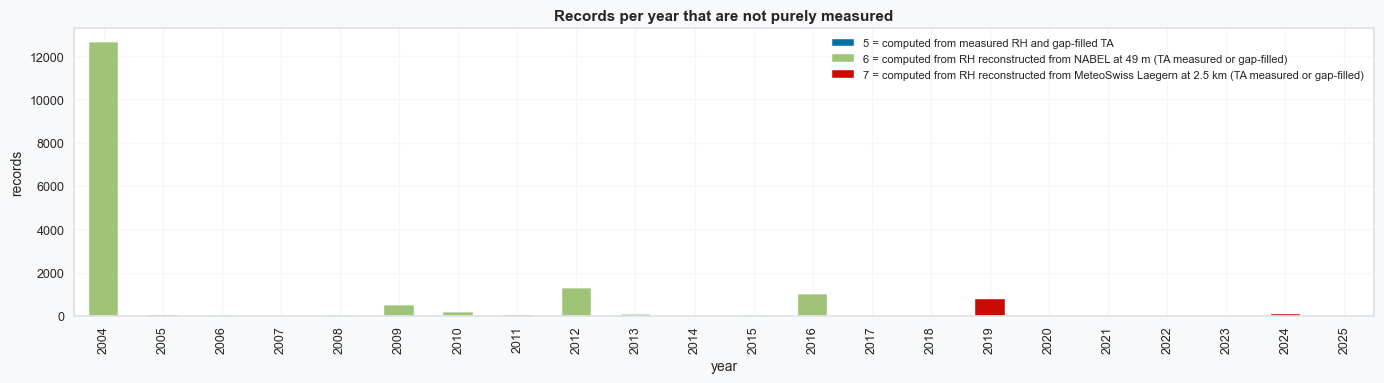

In [16]:
# Records per year and flag, plus the filled ones as a stacked bar chart.
_tab = (pd.crosstab(export_df.index.year, export_df[FLAGCOL])
        .rename(columns=lambda f: FLAG_LEGEND.get(f, f))
        .rename_axis(index='year', columns=None))
_not_measured = _tab.drop(columns=[c for c in _tab.columns if str(c).startswith('0 =')],
                          errors='ignore')
if not _not_measured.empty and _not_measured.to_numpy().sum() > 0:
    ax = _not_measured.plot(kind='bar', stacked=True, figsize=(14, 4),
                            title='Records per year that are not purely measured')
    ax.set_ylabel('records')
    ax.legend(fontsize=8)
    plt.tight_layout()
display(_tab)

***

## 💾 Save to file

In [17]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\07_METEO_VPD_2004-2025.parquet (0.074 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\07_METEO_VPD_2004-2025.parquet


### Verify the written file

Reading the parquet back and checking it directly, rather than trusting the in-memory frame.

In [18]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns:   {list(_written.columns)}")
print(f"index:     {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)")
print(f"missing:   {int(_written[VALCOL].isna().sum())}")
print(f"median:    {float(_written[VALCOL].median()):.3f} kPa")
print(f"min / max: {float(_written[VALCOL].min()):.3f} / {float(_written[VALCOL].max()):.3f} kPa")

assert list(_written.columns) == [VALCOL, FLAGCOL], "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
assert _written[VALCOL].equals(export_df[VALCOL]), "values differ from what was written"
assert _written[FLAGCOL].equals(export_df[FLAGCOL]), "flags differ from what was written"
check_vpd_range(_written[VALCOL], f"{VALCOL} (read back)")
print("\nWritten file verified.")

display(_written[VALCOL].groupby(_written.index.year).median().round(3)
        .rename('yearly median (kPa)'))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\07_METEO_VPD_2004-2025.parquet (0.013 seconds).

columns:   ['VPD_T1_47_1', 'FLAG_VPD_T1_47_1_ISFILLED']
index:     2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)
missing:   0
median:    0.171 kPa
min / max: 0.000 / 4.036 kPa
  VPD_T1_47_1 (read back)            n=385,728  median 0.171  range 0.000..4.036 kPa

Written file verified.


TIMESTAMP_MIDDLE
2004    0.177
2005    0.168
2006    0.179
2007    0.180
2008    0.181
2009    0.191
2010    0.139
2011    0.226
2012    0.173
2013    0.121
2014    0.186
2015    0.234
2016    0.127
2017    0.187
2018    0.179
2019    0.171
2020    0.202
2021    0.132
2022    0.219
2023    0.175
2024    0.099
2025    0.153
Name: yearly median (kPa), dtype: float64

***

## ⚠️ Note for downstream notebooks

`VPD_T1_47_1` is **complete** and **fully computed** — every record follows from `TA` and `RH` by
the formula; no `VPD` model runs.

`FLAG_VPD_T1_47_1_ISFILLED` tells a consumer what each record was computed from:

- `0` — measured `TA` and measured `RH` at 47 m. The only records where nothing upstream was
  modelled or transferred.
- `5` — measured `RH`, with a `TA` that notebook `02` gap-filled. Skilful, but not two measurements.
- `6` — `RH` reconstructed from the NABEL sensor at 49 m (notebook `04`), ~3 % RH uncertainty.
- `7` — `RH` reconstructed from MeteoSwiss Lägern at 2.5 km (notebook `04`), a weaker transfer than
  `6`. Almost all post-2018, plus the 2004 record start.

Two filters cover most uses: `flag == 0` for genuine measurements only, and — since every record
is computed — `flag > 0` for a value that rests on a gap-filled `TA` or a reconstructed `RH`.

#

### The November 2019 outage

One block deserves naming. The 47 m humidity sensor was down from **4 November 2019 04:45 to
19 November 2019 23:45** — **759 consecutive records, 15.8 days**, over half that month, by far the
longest stretch where the tower measured no `RH`.

Before 2019 a gap this long would have been reconstructed from NABEL. After 2018 NABEL is gone, so
notebook `04` reconstructs it from MeteoSwiss Lägern instead: the `VPD` here is **computed from a
Lägern-reconstructed `RH`** and carries flag `7`, not modelled. These 759 records are the bulk of
the flag-7 block — a transfer from a real humidity measurement 2.5 km away, weaker than the
same-tower NABEL transfer but not a model output.

## End of notebook.

In [19]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-21 02:09:50
Finished: 2026-07-21 02:09:56
Runtime:  00:00:05 (hh:mm:ss)
